In [1]:
import xml.etree.ElementTree as ET

In [2]:
import pandas as pd

In [3]:
import os

In [4]:
print(os.getcwd())

C:\Users\user\Desktop\data-analyst-portfolio\portfolio1-cvat-eda


In [5]:
print(os.listdir())

['.ipynb_checkpoints', 'annotations', 'eda_analysis.ipynb', 'raw_images']


In [6]:
def parse_cvat_xml(xml_path):
    """CVAT XML을 읽어서 객체별 정보를 DataFrame으로 반환"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    records = []
    for image in root.findall('image'):
        img_name = image.get('name')
        img_width = image.get('width')
        img_height = image.get('height')
        
        # bbox 형태 (<box>) 찾기
        for box in image.findall('box'):
            records.append({
                'image': img_name,
                'label': box.get('label'),
                'shape_type': 'box',
                'xtl': float(box.get('xtl')),
                'ytl': float(box.get('ytl')),
                'xbr': float(box.get('xbr')),
                'ybr': float(box.get('ybr')),
            })
        
        # polygon 형태 (<polygon>) 찾기
        for poly in image.findall('polygon'):
            records.append({
                'image': img_name,
                'label': poly.get('label'),
                'shape_type': 'polygon',
                'points': poly.get('points'),
            })
    
    return pd.DataFrame(records)

# vehicle bbox 불러오기
df_vehicle = parse_cvat_xml('annotations/vehicle/annotations.xml')
df_vehicle.head()

,image,label,shape_type,xtl,ytl,xbr,ybr
0,10115209.jpg,vehicle,box,0.99,139.80,156.50,246.00
1,10115209.jpg,vehicle,box,1183.00,591.17,1507.20,906.30
2,10115209.jpg,vehicle,box,288.40,633.95,659.20,981.42
3,10115209.jpg,vehicle,box,1784.91,123.08,1919.58,253.87
4,10115209.jpg,vehicle,box,798.00,611.90,1078.00,911.40


In [7]:
df_animal = parse_cvat_xml('annotations/animal/annotations.xml')
df_animal.head()

,image,label,shape_type,points
0,animal/cats_00272.jpg,cat,polygon,"135.19,49.25;93.83,17.62;74.37,24.91;84.71,76...."
1,animal/cats_00278.jpg,cat,polygon,"23.82,5.12;36.76,31.01;37.79,53.49;41.53,68.82..."
2,animal/cats_00286.jpg,cat,polygon,"57.94,20.49;49.22,23.40;40.50,50.15;40.50,86.4..."
3,animal/cats_00287.jpg,cat,polygon,"0.40,128.93;63.66,125.89;98.33,135.01;131.18,1..."
4,animal/cats_00287.jpg,cat,polygon,"208.43,201.31;227.89,158.73;261.96,124.67;291...."


In [8]:
# vehicle: 이미지 수, 라벨 수, 클래스별 개수
print("=== Vehicle ===")
print("전체 라벨 개수:", len(df_vehicle))
print("이미지 수:", df_vehicle['image'].nunique())
print("\n클래스별 개수:")
print(df_vehicle['label'].value_counts())

print("\n=== Animal ===")
print("전체 라벨 개수:", len(df_animal))
print("이미지 수:", df_animal['image'].nunique())
print("\n클래스별 개수:")
print(df_animal['label'].value_counts())

=== Vehicle ===
전체 라벨 개수: 1519
이미지 수: 100

클래스별 개수:
label
vehicle    1402
person      117
Name: count, dtype: int64

=== Animal ===
전체 라벨 개수: 31
이미지 수: 27

클래스별 개수:
label
cat    17
dog    14
Name: count, dtype: int64


In [9]:
print(sorted(df_animal['image'].unique()))

['animal/cats_00272.jpg', 'animal/cats_00278.jpg', 'animal/cats_00286.jpg', 'animal/cats_00287.jpg', 'animal/cats_00290.jpg', 'animal/cats_00291.jpg', 'animal/cats_00302.jpg', 'animal/cats_00308.jpg', 'animal/cats_00322.jpg', 'animal/cats_00324.jpg', 'animal/cats_00326.jpg', 'animal/cats_00329.jpg', 'animal/cats_00341.jpg', 'animal/dogs_00011.jpg', 'animal/dogs_00013.jpg', 'animal/dogs_00017.jpg', 'animal/dogs_00036.jpg', 'animal/dogs_00042.jpg', 'animal/dogs_00097.jpg', 'animal/dogs_00103.jpg', 'animal/dogs_00221.jpg', 'animal/dogs_00222.jpg', 'animal/dogs_00271.jpg', 'animal/dogs_00284.jpg', 'animal/dogs_00285.jpg', 'animal/dogs_00340.jpg', 'animal/dogs_00350.jpg']


In [10]:
# vehicle bbox 크기 계산 (가로, 세로, 면적)
df_vehicle['width'] = df_vehicle['xbr'] - df_vehicle['xtl']
df_vehicle['height'] = df_vehicle['ybr'] - df_vehicle['ytl']
df_vehicle['area'] = df_vehicle['width'] * df_vehicle['height']

print("=== Vehicle bbox 크기 통계 ===")
print(df_vehicle.groupby('label')[['width', 'height', 'area']].describe())

=== Vehicle bbox 크기 통계 ===
          width                                                            \
          count        mean        std    min      25%      50%       75%   
label                                                                       
person    117.0   42.672308  26.257322  15.50  24.9700   31.830   48.2900   
vehicle  1402.0  167.359615  91.504586  24.87  98.9475  143.745  222.6825   

                 height              ...                    area  \
            max   count        mean  ...     75%     max   count   
label                                ...                           
person   142.45   117.0  103.602222  ...  147.12  249.93   117.0   
vehicle  758.59  1402.0  137.326890  ...  163.19  804.09  1402.0   

                                                                       \
                 mean           std       min         25%         50%   
label                                                                   
person    5698.703369   652

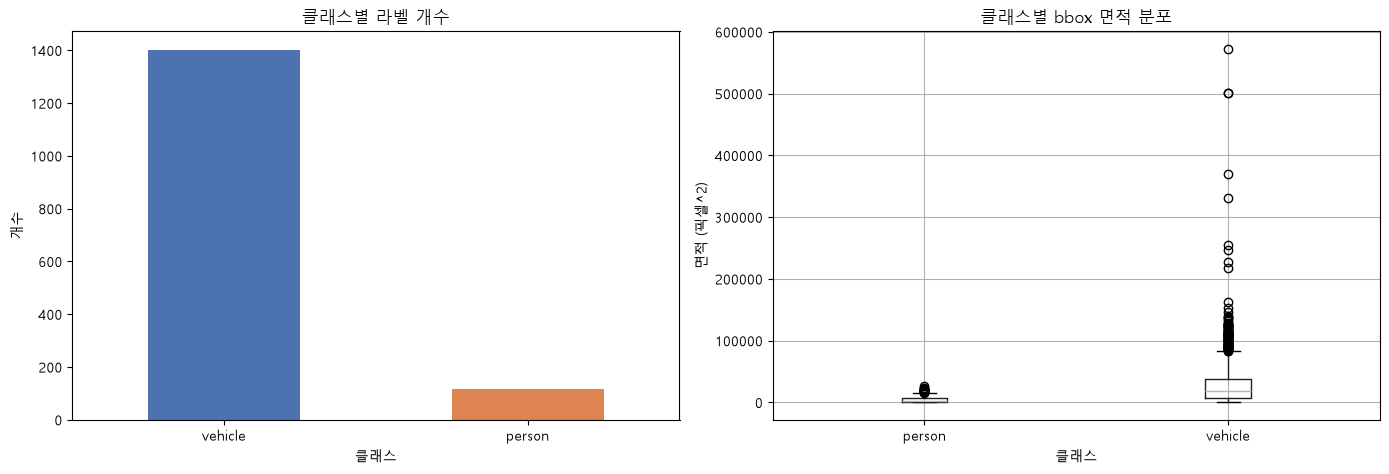

In [11]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 클래스별 개수 막대그래프
df_vehicle['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('클래스별 라벨 개수')
axes[0].set_xlabel('클래스')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=0)

# 2) 클래스별 area(면적) 분포 - boxplot
df_vehicle.boxplot(column='area', by='label', ax=axes[1])
axes[1].set_title('클래스별 bbox 면적 분포')
axes[1].set_xlabel('클래스')
axes[1].set_ylabel('면적 (픽셀^2)')
plt.suptitle('')  # boxplot 기본 제목 제거

plt.tight_layout()
plt.show()

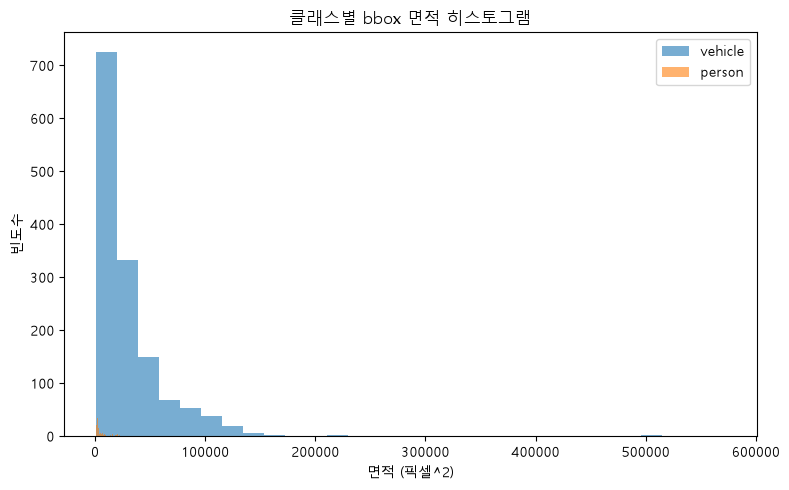

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

# 클래스별로 겹쳐서 히스토그램 그리기
for label in df_vehicle['label'].unique():
    subset = df_vehicle[df_vehicle['label'] == label]
    ax.hist(subset['area'], bins=30, alpha=0.6, label=label)

ax.set_title('클래스별 bbox 면적 히스토그램')
ax.set_xlabel('면적 (픽셀^2)')
ax.set_ylabel('빈도수')
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# animal polygon 불러오기
df_animal = parse_cvat_xml('annotations/animal/annotations.xml')
print(df_animal.head())
print(df_animal['points'].iloc[0])  # 첫 번째 좌표 문자열 실제 모양 확인

                   image label shape_type  \
0  animal/cats_00272.jpg   cat    polygon   
1  animal/cats_00278.jpg   cat    polygon   
2  animal/cats_00286.jpg   cat    polygon   
3  animal/cats_00287.jpg   cat    polygon   
4  animal/cats_00287.jpg   cat    polygon   

                                              points  
0  135.19,49.25;93.83,17.62;74.37,24.91;84.71,76....  
1  23.82,5.12;36.76,31.01;37.79,53.49;41.53,68.82...  
2  57.94,20.49;49.22,23.40;40.50,50.15;40.50,86.4...  
3  0.40,128.93;63.66,125.89;98.33,135.01;131.18,1...  
4  208.43,201.31;227.89,158.73;261.96,124.67;291....  
135.19,49.25;93.83,17.62;74.37,24.91;84.71,76.62;102.96,126.50;65.24,144.14;35.44,183.07;21.45,243.89;3.81,332.70;0.16,367.98;50.04,400.22;57.34,434.89;78.02,442.80;102.35,429.42;106.61,448.88;101.74,470.17;131.54,481.73;156.48,467.13;155.88,460.44;183.25,465.30;199.06,448.88;185.07,428.20;188.72,411.17;203.32,423.33;239.82,416.03;228.26,389.27;192.98,372.24;213.66,323.58;208.80,267.01;229.48,208

In [14]:
def parse_points(points_str):
    """
    CVAT points 문자열을 좌표 리스트로 변환
    입력: "135.19,49.25;93.83,17.62;..."
    출력: [(135.19, 49.25), (93.83, 17.62), ...]
    """
    coords = []
    for point in points_str.split(';'):      # ';' 기준으로 점 하나씩 자르기
        x_str, y_str = point.split(',')       # ',' 기준으로 x, y 분리
        coords.append((float(x_str), float(y_str)))  # 문자열 → 숫자(float)로 변환
    return coords

# 테스트
test = df_animal['points'].iloc[0]
result = parse_points(test)
print(result[:3])  # 앞 3개 점만 확인

[(135.19, 49.25), (93.83, 17.62), (74.37, 24.91)]


In [15]:
def shoelace_area(points):
    n = len(points)
    area = 0
    for i in range(n):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % n]
        area += x1 * y2 - x2 * y1
    return abs(area) / 2

In [16]:
# 1. points 문자열 → 좌표 리스트로 변환한 컬럼 추가
df_animal['coords'] = df_animal['points'].apply(parse_points)

# 2. Shoelace 함수로 면적 계산해서 새 컬럼 추가
df_animal['area'] = df_animal['coords'].apply(shoelace_area)

# 확인
df_animal[['image', 'label', 'area']].head()

,image,label,area
0,animal/cats_00272.jpg,cat,74427.49965
1,animal/cats_00278.jpg,cat,23023.44335
2,animal/cats_00286.jpg,cat,56837.99960
3,animal/cats_00287.jpg,cat,55762.91105
4,animal/cats_00287.jpg,cat,43805.82070


In [17]:
# label 개수 확인 (dog도 잘 들어왔는지)
print(df_animal['label'].value_counts())

# cat vs dog 면적 통계 (개수, 평균, 최소, 최대 등)
print(df_animal.groupby('label')['area'].describe())

label
cat    17
dog    14
Name: count, dtype: int64
       count          mean           std         min           25%  \
label                                                                
cat     17.0  60208.662953  25019.649837  20331.5873  45770.366200   
dog     14.0  59025.377114  27660.539433  19260.2652  40726.349488   

               50%           75%           max  
label                                           
cat    56837.99960  71148.826700  127042.05755  
dog    58688.77905  69150.884488  116945.03510  


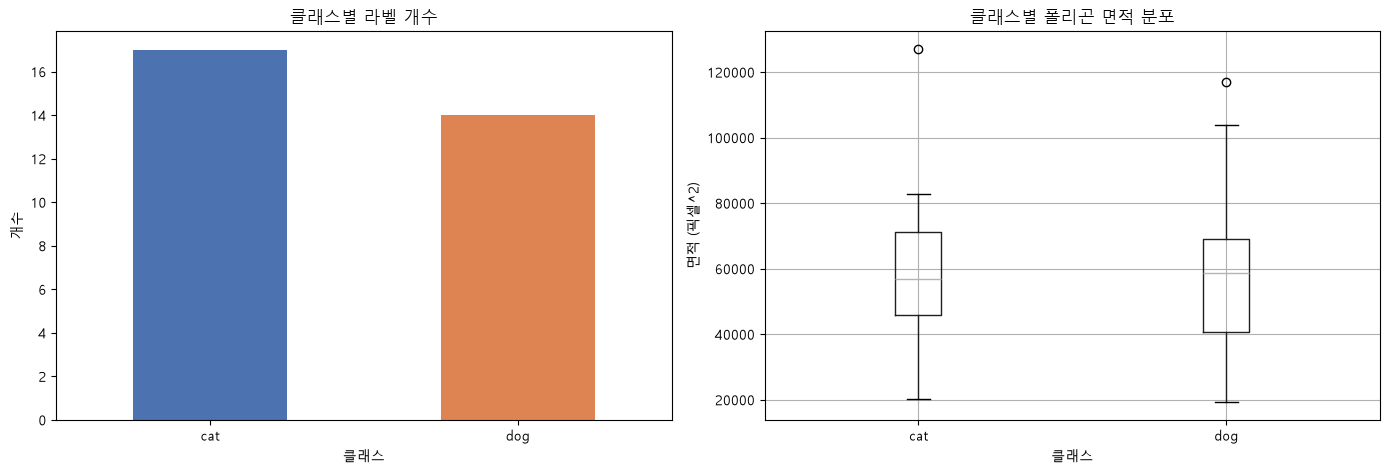

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 클래스별 개수 막대그래프
df_animal['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('클래스별 라벨 개수')
axes[0].set_xlabel('클래스')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=0)

# 2) 클래스별 area(면적) 분포 - boxplot
df_animal.boxplot(column='area', by='label', ax=axes[1])
axes[1].set_title('클래스별 폴리곤 면적 분포')
axes[1].set_xlabel('클래스')
axes[1].set_ylabel('면적 (픽셀^2)')
plt.suptitle('')
plt.tight_layout()
plt.show()

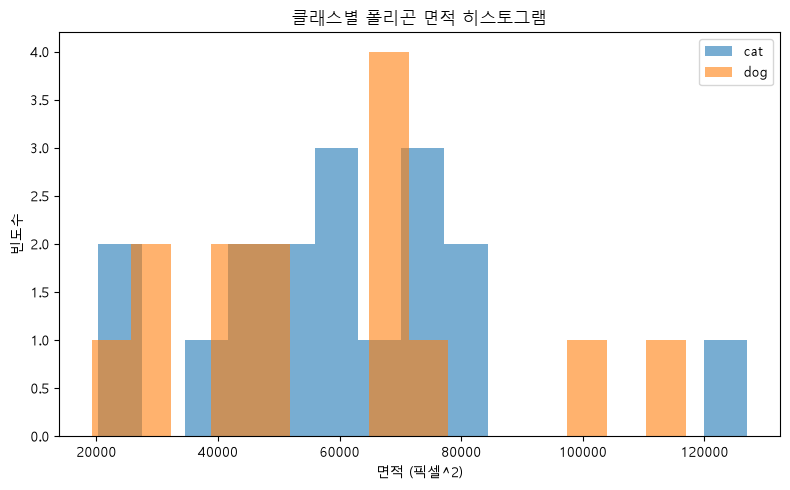

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

# 클래스별로 겹쳐서 히스토그램 그리기
for label in df_animal['label'].unique():
    subset = df_animal[df_animal['label'] == label]
    ax.hist(subset['area'], bins=15, alpha=0.6, label=label)  # 데이터 개수 적어서 bins 30→15로 조정

ax.set_title('클래스별 폴리곤 면적 히스토그램')
ax.set_xlabel('면적 (픽셀^2)')
ax.set_ylabel('빈도수')
ax.legend()
plt.tight_layout()
plt.show()